In [1]:
import struct
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix

I0000 00:00:1781058550.636021  104224 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781058550.699742  104224 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781058552.124841  104224 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
with open('./datasets/mnist/train-images.idx3-ubyte', 'rb') as f:
    _, n, rows, cols = struct.unpack('>IIII', f.read(16))
    train_images = np.fromfile(f, dtype=np.uint8).reshape(n, rows, cols)
    # LSTM input: (N, time_steps, features) → channel 불필요, shape (60000, 28, 28)

with open('./datasets/mnist/train-labels.idx1-ubyte', 'rb') as f:
    struct.unpack('>II', f.read(8))
    train_labels = np.fromfile(f, dtype=np.uint8)

with open('./datasets/mnist/t10k-images.idx3-ubyte', 'rb') as f:
    _, n, rows, cols = struct.unpack('>IIII', f.read(16))
    test_images = np.fromfile(f, dtype=np.uint8).reshape(n, rows, cols)

with open('./datasets/mnist/t10k-labels.idx1-ubyte', 'rb') as f:
    struct.unpack('>II', f.read(8))
    test_labels = np.fromfile(f, dtype=np.uint8)

# uint8(0 ~ 255) -> float32(0.0 ~ 1.0) 정규화
train_images = train_images.astype(np.float32) / 255.0
test_images  = test_images.astype(np.float32)  / 255.0

In [4]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
test_dataset  = tf.data.Dataset.from_tensor_slices((test_images,  test_labels))

# shuffle(): 학습 데이터 순서를 섞어 편향 방지
# prefetch(): 다음 batch를 background에서 미리 load → GPU 대기 시간 감소
train_dataset = train_dataset.shuffle(1000).batch(64).prefetch(tf.data.AUTOTUNE)
test_dataset  = test_dataset.batch(64).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1781058565.695863  104224 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 701 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


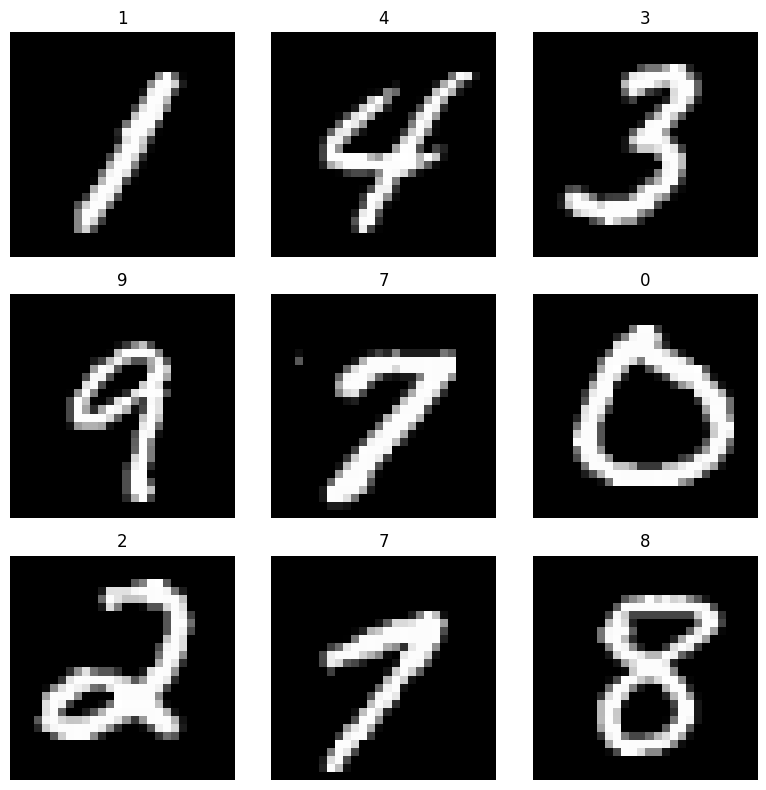

In [5]:
CLASSES = tuple(str(i) for i in range(10))

sample_images, sample_labels = next(iter(train_dataset))

figure = plt.figure(figsize=(8, 8))
indices = np.random.choice(sample_images.shape[0], 9, replace=False)

for i, idx in enumerate(indices, 1):
    figure.add_subplot(3, 3, i)
    plt.title(CLASSES[sample_labels[idx].numpy()])
    plt.axis("off")
    plt.imshow(sample_images[idx].numpy(), cmap="gray")

plt.tight_layout()
plt.show()

**layers.LSTM(units, return_sequences, activation, recurrent_activation, dropout, recurrent_dropout)**
* **units**: hidden state(h_t) 및 cell state(c_t) 크기. 128 시작 → 성능 부족 시 *2, overfitting 시 /2
* **return_sequences**: 중간 LSTM 레이어: True (모든 time step 반환), 마지막: False (many-to-one)
* **activation**: hidden state 계산에 사용하는 활성화 함수. 기본값 'tanh'
* **recurrent_activation**: forget/input/output gate에 사용하는 활성화 함수. 기본값 'sigmoid'
* **dropout**: 입력(x_t)에 적용하는 dropout 비율
* **recurrent_dropout**: hidden state(h_t)에 적용하는 dropout 비율

> **SimpleRNN vs LSTM**
> * SimpleRNN은 h_t만 관리하지만, LSTM은 단기 기억(h_t)과 장기 기억(c_t, cell state)을 분리해 관리한다.
> * forget gate(과거 정보 삭제), input gate(새 정보 저장), output gate(출력 결정)를 통해 gradient vanishing 문제를 개선하여, 긴 시퀀스에서도 효과적으로 학습한다.

In [7]:
def LSTM():
    inputs = keras.Input(shape=(28, 28))  # (time_steps=28, features=28)

    # Layer 1: return_sequences=True → 모든 time step의 hidden state를 다음 LSTM 레이어로 전달
    x = layers.LSTM(128, return_sequences=True, dropout=0.3)(inputs)

    # Layer 2: return_sequences=False → 마지막 time step의 hidden state만 반환 (many-to-one)
    x = layers.LSTM(64, return_sequences=False, dropout=0.3)(x)

    # Classifier
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(10)(x)  # logits (softmax는 loss 함수 내부에서 처리)

    return keras.Model(inputs, outputs, name="lstm_mnist")


model = LSTM()
model.summary()

Model: "lstm_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 28, 128)        │        80,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,602 (525.79 KB)

 Trainable params: 134,602 (525.79 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

callbacks = [
    # val_loss가 3 epoch 동안 개선되지 않으면 학습 조기 종료
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True  # 가장 좋은 가중치로 자동 복원
    ),
    # val_loss가 개선되지 않으면 learning rate를 0.5배로 감소
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
]

history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset,
    callbacks=callbacks,
)

Epoch 1/10


I0000 00:00:1781058608.498617  104362 cuda_dnn.cc:461] Loaded cuDNN version 92301


938/938 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.7537 - loss: 0.7426 - val_accuracy: 0.9371 - val_loss: 0.2036 - learning_rate: 0.0010
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9241 - loss: 0.2622 - val_accuracy: 0.9657 - val_loss: 0.1115 - learning_rate: 0.0010
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9449 - loss: 0.1922 - val_accuracy: 0.9738 - val_loss: 0.0881 - learning_rate: 0.0010
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9560 - loss: 0.1525 - val_accuracy: 0.9804 - val_loss: 0.0689 - learning_rate: 0.0010
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9612 - loss: 0.1328 - val_accuracy: 0.9812 - val_loss: 0.0598 - learning_rate: 0.0010
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9665 - loss: 0.1155 - val_accuracy: 0.9841 - val_loss: 0.0535 - learning_rate: 0.0010
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9699 - loss: 0.1024 - val_accura

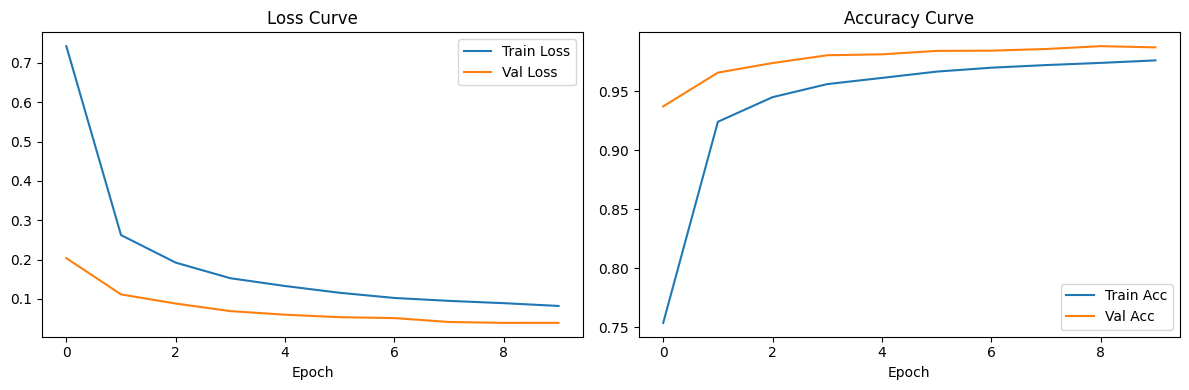

In [9]:
hist = history.history

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hist["loss"],     label="Train Loss")
ax1.plot(hist["val_loss"], label="Val Loss")
ax1.set_title("Loss Curve")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(hist["accuracy"],     label="Train Acc")
ax2.plot(hist["val_accuracy"], label="Val Acc")
ax2.set_title("Accuracy Curve")
ax2.set_xlabel("Epoch")
ax2.legend()

plt.tight_layout()
plt.show()

Test Loss: 0.0390 | Test Accuracy: 0.9881


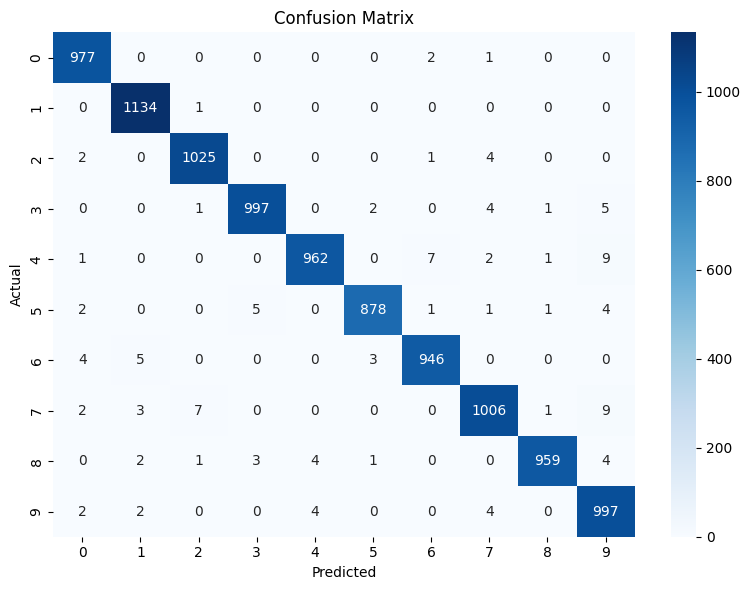

In [10]:
test_loss, test_acc = model.evaluate(test_dataset, verbose=0)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

all_preds  = []
all_labels = []

for images, labels in test_dataset:
    logits = model(images, training=False)  # training=False: Dropout 비활성화
    preds  = tf.argmax(logits, axis=1).numpy()
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASSES, yticklabels=CLASSES,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

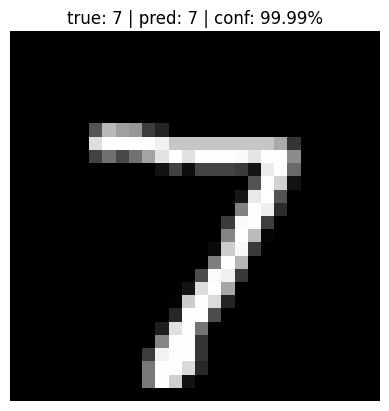

In [11]:
sample_images, sample_labels = next(iter(test_dataset))

idx          = 0
single_image = sample_images[idx:idx+1]  # (1, 28, 28) shape 유지
true_label   = sample_labels[idx].numpy()

logits     = model(single_image, training=False)
probs      = tf.nn.softmax(logits, axis=1).numpy()[0]
pred_label = np.argmax(probs)
confidence = probs[pred_label]

plt.imshow(single_image[0].numpy(), cmap="gray")
plt.title(
    f"true: {CLASSES[true_label]} | "
    f"pred: {CLASSES[pred_label]} | "
    f"conf: {confidence:.2%}"
)
plt.axis("off")
plt.show()